In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df1 = pd.read_csv('..\data\cleaned\employment_cleaned.csv')
df2 = pd.read_csv('..\data\cleaned\skills.csv')

df1.head()
# df2.head(15)

<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:2: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\DELL\AppData\Local\Temp\ipykernel_15476\2256641048.py:1: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df1 = pd.read_csv('..\data\cleaned\employment_cleaned.csv')
C:\Users\DELL\AppData\Local\Temp\ipykernel_15476\2256641048.py:2: SyntaxWarning: "\d" is an invalid escape sequen

,id,AgeAbove35,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,0,False,Master,1,Man,False,Dev,7,4,Sweden,51552.0,"['C++', 'Python', 'Git', 'PostgreSQL']",4,0
1,1,0,False,Undergraduate,1,Man,False,Dev,12,5,Spain,46482.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'Node...",12,1
2,2,0,False,Master,1,Man,False,Dev,15,6,Germany,77290.0,"['C', 'C++', 'Java', 'Perl', 'Ruby', 'Git', 'R...",7,0
3,3,0,False,Undergraduate,1,Man,False,Dev,9,6,Canada,46135.0,"['Bash/Shell', 'HTML/CSS', 'JavaScript', 'PHP'...",13,0
4,4,1,False,PhD,0,Man,False,NotDev,40,30,Singapore,160932.0,"['C++', 'Python']",2,0


In [10]:
df1.ComputerSkills.value_counts()

ComputerSkills
11     4656
10     4551
12     4524
13     4483
14     4329
       ... 
56        1
79        1
64        1
101       1
107       1
Name: count, Length: 73, dtype: int64

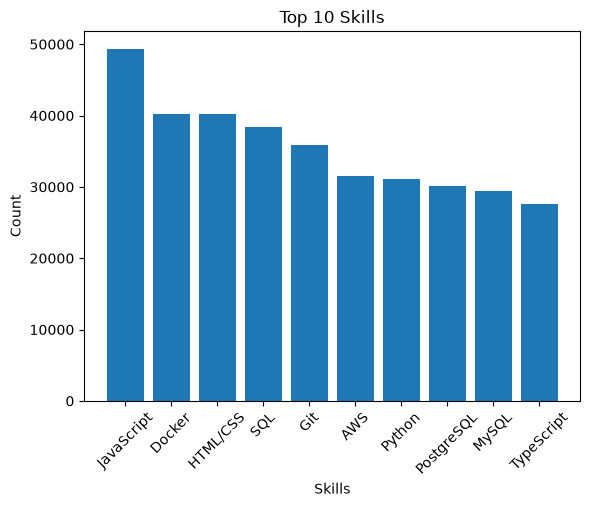

In [28]:
# the most frequent skill
top_skills= df2.HaveWorkedWith.value_counts().head(10)
plt.bar(top_skills.index, top_skills.values)
plt.title('Top 10 Skills')  
plt.xlabel('Skills')
plt.ylabel('Count') 
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Employed with no skills or  Having skills but not employed

emp_no_skills = df1[(df1.ComputerSkills == 0) & (df1.Employed == 1)]
print(f"Number of employed individuals with no computer skills: {len(emp_no_skills)}")
emp_with_skills = df1[(df1.ComputerSkills == 1) & (df1.Employed == 0)]
print(f"Number of individuals with computer skills but not employed: {len(emp_with_skills)}")

Number of employed individuals with no computer skills: 0
Number of individuals with computer skills but not employed: 370


In [95]:
df1.AgeAbove35.value_counts()
# df2.HaveWorkedWith.value_counts()

AgeAbove35
0    47819
1    25643
Name: count, dtype: int64

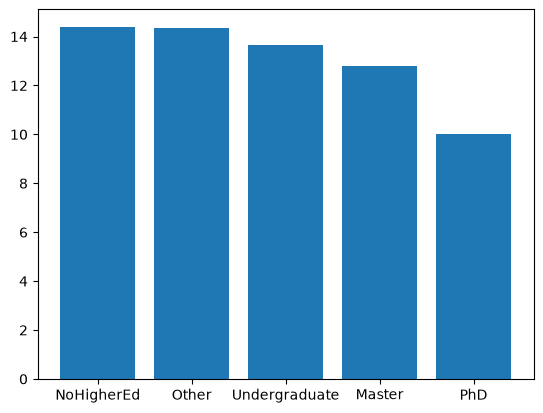

In [ ]:
elevel_skills = df1.groupby('EdLevel')['ComputerSkills'].mean().sort_values(ascending=False)    

plt.bar(elevel_skills.index, elevel_skills.values)
plt.show()

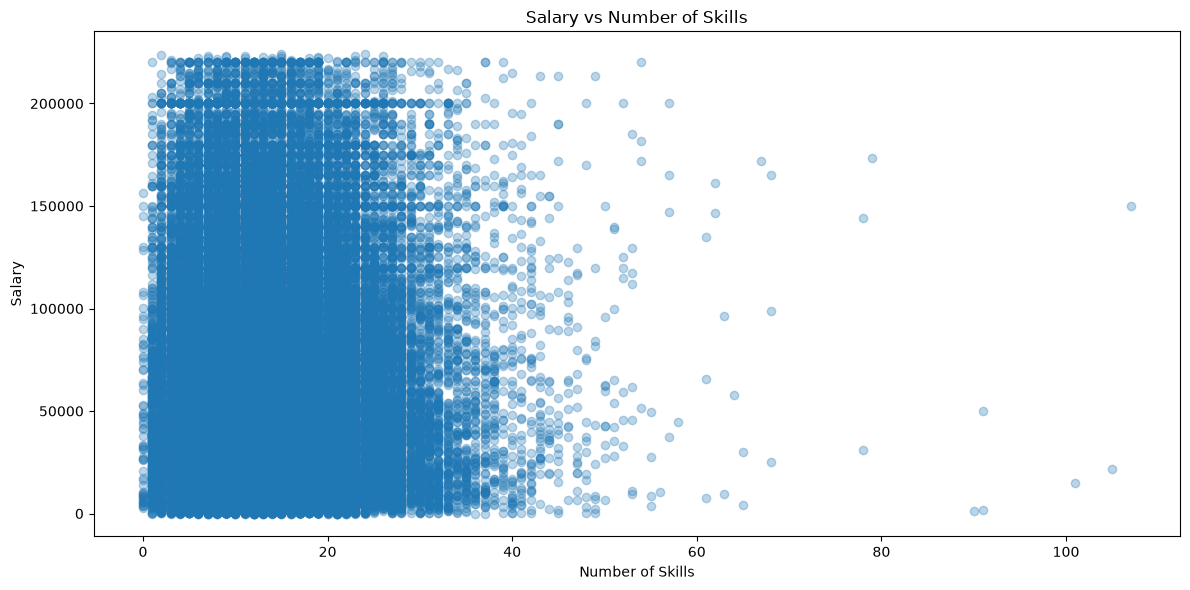

In [ ]:
# skills vs salary 
salary_skills = df1.groupby('ComputerSkills')['PreviousSalary'].mean() 
salary_skills.head(10)


plt.figure(figsize=(12,6))        
plt.scatter(df1['ComputerSkills'], df1['PreviousSalary'], alpha=0.3)
plt.title('Salary vs Number of Skills')
plt.xlabel('Number of Skills')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()


Average skills - Under 35: 13.74
Average skills - 35+: 12.84


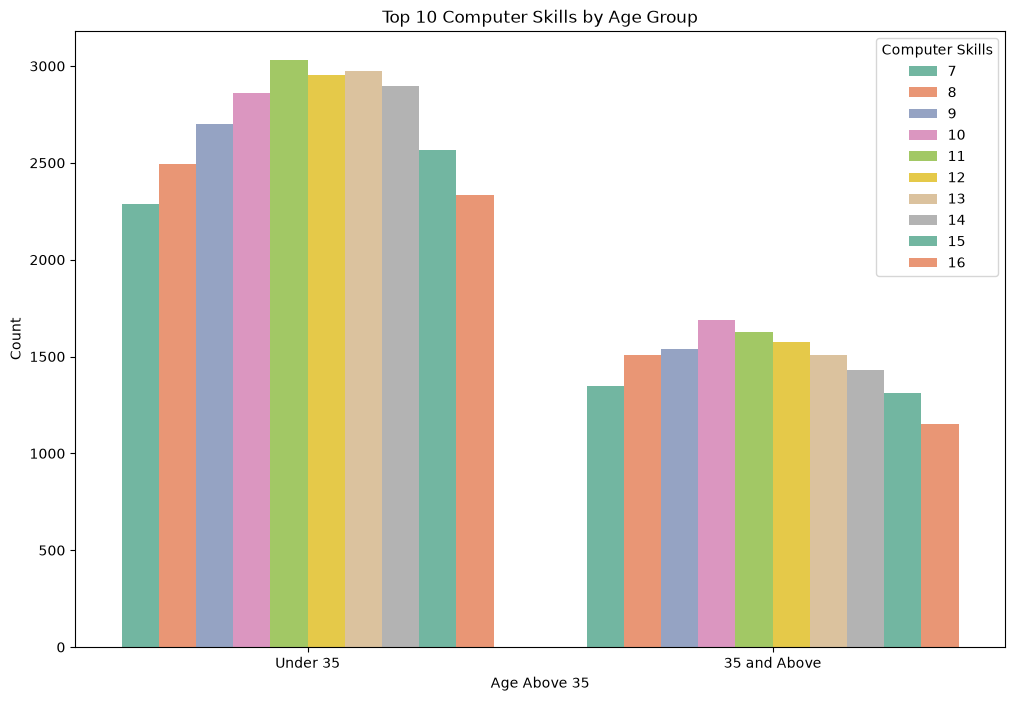

In [93]:
if 'AgeAbove35' in df1.columns:
        young_skills = df1[df1['AgeAbove35'] == 0]['ComputerSkills']
        old_skills = df1[df1['AgeAbove35'] == 1]['ComputerSkills']
        
        print(f"Average skills - Under 35: {young_skills.mean():.2f}")
        print(f"Average skills - 35+: {old_skills.mean():.2f}")  

top_skills = df1.ComputerSkills.value_counts().head(10).index.tolist()
df_top_skills = df1[df1['ComputerSkills'].isin(top_skills)]

plt.figure(figsize=(12, 8))
sns.countplot(x='AgeAbove35', hue='ComputerSkills', data=df_top_skills, palette='Set2')
plt.title('Top 10 Computer Skills by Age Group')
plt.xlabel('Age Above 35')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Under 35', '35 and Above'])
plt.legend(title='Computer Skills', loc='upper right')
plt.show()
       

In [ ]:
# not complete yet!!!
if 'YearsCode_num' in df1.columns and 'Employed' in df1.columns and 'ComputerSkills' in df1.columns:
   junior = df1[df1['YearsCode_num'] <= 2]
   senior = df1[df1['YearsCode_num'] > 5]
    
   junior_corr = junior['ComputerSkills'].corr(junior['Employed'])
   senior_corr = senior['ComputerSkills'].corr(senior['Employed'])
    
   print(f"Correlation between skills and employment for juniors: {junior_corr:.3f}")
   print(f"Correlation between skills and employment for seniors: {senior_corr:.3f}")